## Cell 1: Load and Inspect Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data_sample.csv", encoding="latin1")

print("-- SHAPE --")
print(df.shape)

print("\n-- DATA TYPES & INFO --")
print(df.info())

print("\n-- MISSING VALUES --")
print(df.isnull().sum())

print("\n-- DUPLICATES --")
print("Duplicate rows", df.duplicated().sum())

-- SHAPE --
(2823, 25)

-- DATA TYPES & INFO --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 

## Cell 2: Data Cleaning

In [3]:

df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

df = df.fillna("Unknown")

print("Missing values after cleaning")
print(df.isnull().sum())

Missing values after cleaning
ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64


## Cell 3: Summary Statistics & Breakdown

In [4]:
print("--- SALES SUMMARY ---")
print(df["SALES"].describe())

print("\n--- ORDER STATUS (%) ---")
print(df["STATUS"].value_counts(normalize=True) * 100)

print("\n--- ORDERS BY YEAR ---")
print(df["YEAR_ID"].value_counts().sort_index())

print("\n--- ORDERS BY PRODUCT LINE ---")
print(df['PRODUCTLINE'].value_counts)

--- SALES SUMMARY ---
count     2823.000000
mean      3553.889072
std       1841.865106
min        482.130000
25%       2203.430000
50%       3184.800000
75%       4508.000000
max      14082.800000
Name: SALES, dtype: float64

--- ORDER STATUS (%) ---
STATUS
Shipped       92.702798
Cancelled      2.125399
Resolved       1.664896
On Hold        1.558626
In Process     1.452356
Disputed       0.495926
Name: proportion, dtype: float64

--- ORDERS BY YEAR ---
YEAR_ID
2003    1000
2004    1345
2005     478
Name: count, dtype: int64

--- ORDERS BY PRODUCT LINE ---
<bound method IndexOpsMixin.value_counts of 0       Motorcycles
1       Motorcycles
2       Motorcycles
3       Motorcycles
4       Motorcycles
           ...     
2818          Ships
2819          Ships
2820          Ships
2821          Ships
2822          Ships
Name: PRODUCTLINE, Length: 2823, dtype: object>


## Cell 4: Visualizations & Export Cleaned File

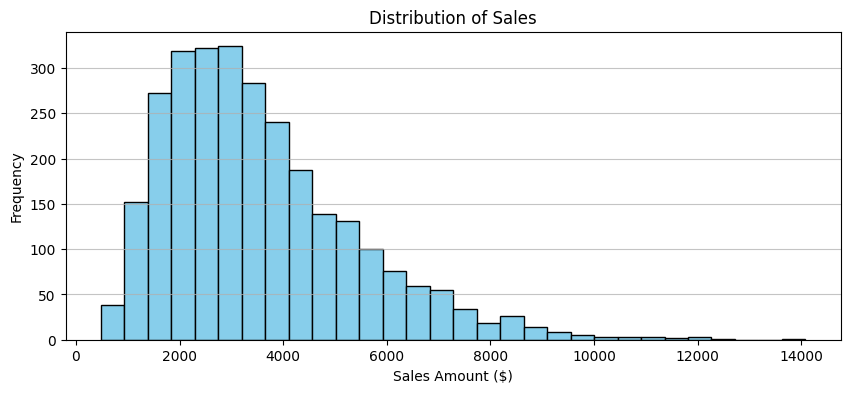

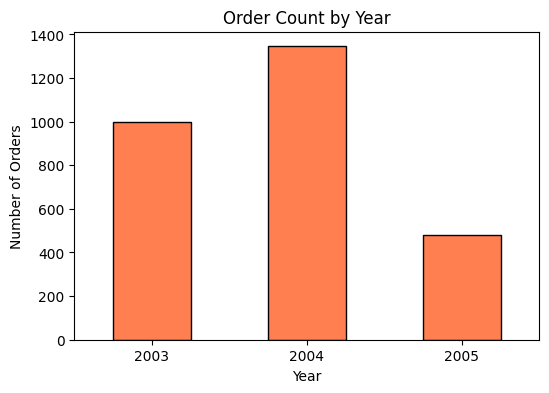

Cleaned dataset successfully saved as 'cleaned_sales_data.csv'


In [5]:
# 1. Histogram of Sales Amount
plt.figure(figsize=(10, 4))
plt.hist(df['SALES'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Bar Chart of Orders by Year
plt.figure(figsize=(6, 4))
df['YEAR_ID'].value_counts().sort_index(ascending=True).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Order Count by Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.show()

# Save cleaned dataset locally
df.to_csv('cleaned_sales_data.csv', index=False)
print("Cleaned dataset successfully saved as 'cleaned_sales_data.csv'")